In [1]:
# other possible imports needed
import skimage
from skimage.measure import regionprops_table
import matplotlib.pyplot as plt
import pandas as pd
import cv2
import spectrochempy as scp

"<img src='data:image/png;base64,iVBORw0KGgoAAAANSUhEUgAAABgAAAAYCAYAAADgdz34AAAA AXNSR0IArs4c6QAAAAlwSFlzAAAJOgAACToB8GSSSgAAAetpVFh0WE1MOmNvbS5hZG9iZS54bXAAAAAA ADx4OnhtcG1ldGEgeG1sbnM6eD0iYWRvYmU6bnM6bWV0YS8iIHg6eG1wdGs9IlhNUCBDb3JlIDUuNC4w Ij4KICAgPHJkZjpSREYgeG1sbnM6cmRmPSJodHRwOi8vd3d3LnczLm9yZy8xOTk5LzAyLzIyLXJkZi1z eW50YXgtbnMjIj4KICAgICAgPHJkZjpEZXNjcmlwdGlvbiByZGY6YWJvdXQ9IiIKICAgICAgICAgICAg eG1sbnM6eG1wPSJodHRwOi8vbnMuYWRvYmUuY29tL3hhcC8xLjAvIgogICAgICAgICAgICB4bWxuczp0 aWZmPSJodHRwOi8vbnMuYWRvYmUuY29tL3RpZmYvMS4wLyI+CiAgICAgICAgIDx4bXA6Q3JlYXRvclRv b2w+bWF0cGxvdGxpYiB2ZXJzaW9uIDIuMS4wLCBodHRwOi8vbWF0cGxvdGxpYi5vcmcvPC94bXA6Q3Jl YXRvclRvb2w+CiAgICAgICAgIDx0aWZmOk9yaWVudGF0aW9uPjE8L3RpZmY6T3JpZW50YXRpb24+CiAg ICAgIDwvcmRmOkRlc2NyaXB0aW9uPgogICA8L3JkZjpSREY+CjwveDp4bXBtZXRhPgqNQaNYAAAGiUlE QVRIDY1We4xU1Rn/3XPuYx47u8w+hnU38hTcuoUEt/6D2y4RB0ME1BoEd9taJaKh9CFiN7YGp7appUAM NmktMZFoJTYVLVQ0smsy26CN0SU1QgsuFAaW3WVmx33N677O6XfuyoIxTXqSO/fec+75fd93vt/3/UbD V0aKSZmCpkFMLz3T9utuu2N+o98aDSMBKVAo89z5y+zEz3ZafcCOfvWdlGCalqKn1Bf71CygTd+mf1es SOnpdMpTb+vWpTZuWVfe3jLPa5tzHYNm0T5N0gpdkkHaDBeGBU6d1/t/fyS8+/CbqdfUvmsx1PuMgc2b Nxv79u1zgd31r+7JH1jbIZKxWRXAcYUQ8IWvBfBXNjEuJWPgMA02NR7C3/pYT9fjdZ3A9tGrWF8YSJHn qcDz3y7q2T967PZv+gnYJdd1mEZ+62zGDQV/dQgKhmLzDNOXCEWM3j6eTT5Y3w78dOBKJLR1PQf+4ivP j76UPZnssBN+wbM9Aet/AV81Mf1EEULXYfOobvX2WWQk0aoioXwwSmirOlioY0mu8BIouzYl7P8GV3vp qCCEZvlFz769w08oLDWvyKIyL1asSm28d6WfzA97ztvvV1kexUMsmhlkULEkuGYmFYC6AvfUrITnwUKl 5K79lkjeSSRRTCTbQPd95e1WzMbZSya74XoXAxctCllCnbECMOjZNGRwvzIXnD85wbkMmKK+U045Dtdi 8Qp+SAxU2GTg2bYlC9224pgvmSb54vkVTBQYyhUt2KjAMyMmPjwRQW5Mh2WKwJhlBh6jVGagFM84wZnQ 4bpC0Rt4pk1PbSt0NDcxDA5xryosDHWgtbM0DGZDWLSoiDMDYeQnGVrmOThxLozB0RAaahzkJzjKNqcI QBymJFMkOlN8Dqjpg0XYTx5xO/QbmmUrqIjGJznq47TqTaClKYfjp+PInLMwnOdYvtQBZ2XcunQY+VwI o4U4muoFEjVEFE6lQyEUKzHYfgQG9ylCyngU+CxjtOqxCDGHcCsOMCs6iQul5ZiStdATYxjMZXDLTUVw LY8Jey4uOh2IxjwsrP8UXJYxUrkZrghBahzV5iXU6gNkq0Z1EzIsUBUSCV2nEOHo0LVxHCpuxabJJdhi 5PFnvw5vLXwXIfNZvD/+JNo/X40NegE54sUaazl+UL8XD1x+FB9Ijjt4EQfdGN6J/x131LwIV9ap/AYs 0x1fz1ZKFbh6A7qKy/By9Dg6G36Ep91vUJJ15Cqr0Z67E8/HzmBrw1OwxWyM+3Mo6BAuSB17oyfx0Oyl 2DN0Hqs/70Cx6hBCvESFUY1ShWXZZEE7OTAYxZzaPH4TuoiusZvRnunFy2NbiHYuBp2vB66srX4vMEjp RKPxKXmnoQ4+Mn4DPiv8CYcrs3GfNUXJLtM+alSOhrMj/KT+wBNW3+E/2liywNO3iSflbaFva/+stGDT xE0E9Sjaox8HBhxpEamzMGSEaFKg+mjEddzDh1MxTDq3YV1kGBsjfwW3S9Cqanjmko+ndlb1UR3s6K8J lfphNWq9Ew/7c61T2BB/EbcaNkb8GBaE0tANH7/M34PLdhJDzjIcL9xPbdTG6zyM72Y+wXPHmvB489No fm0b5HnbQ9Rgp/7DSSd29AeVvPeNyK6JcYl/yQVi5dBjuGvoV/gaJe47s45QUxrDmcYX0MBsdF7egvXZ 7+O0vZA4X8QmOQWjlSK7RDz5wIM30gp9UbWcGjXxhzdDu1SiNSpx6kcQB57rPnr/3dlkZarWLnlRq5oP ET1dOCIOk4wALib9eeS5iygfhkd09H0DWphB/+gs+PcOAS+ssrFmmXXgVfR0de9cpbAJfH3Q1jofW9DZ k56dDcVsq9YcsoUMEd1qyLoT3BX1YiyHMJuk97hyjqIoE91t+NcTLeN0ZrfMoXatZbu6G0h4VG+ibqq0 IJVK6cAjo6serG3vSUezCMct0yQeSOFJSUImqb2qbknUpDqlZxE0QZ+ZUpSlZx79h4Nda6zef9dlk121 JDjbR5XggPRZlRnS6bRQRtLpn4++cuie/Yvn2svmNxuLw9WCcYIl4fEoTEGiSTUqJdfgU+8ROqf1iMkL zS389YtNPXc/PH8l8ONBJZkHD+4JtD04HmVEDWWErmBhzV2/2LB1bemJG6krzv2S6NOHUgtEP0Oif5pE /3fHoruP7N8RiP61GArzSwbUhJJQpXJKiKbfr/3bIhKq76sKPUdF9NW/LSqfSn6vjv8C45H/6FSgvZQA AAAASUVORK5CYII=' style='height:25px; border-radius:12px; display:inline-block; float:left; vertical-align:middle'>",SpectroChemPy's API - v.0.8.1©Copyright 2014-2026 - A.Travert & C.Fernandez @ LCS


In [1]:
# import for simple code
import numpy as np

In [2]:
# loading the data set
data = np.load('/Users/sunnyyunseolee/Desktop/testingdata.npz')
wavenumber = data['wavenumber']
spectra_data = data['imagedata']

In [3]:
# checking the data-set
print(data.files) # ['__header__', '__version__', '__globals__', 'exc_wlength', 'wavelength', 'wavenumber', 'imagedata', 'wavenumberlist', 'datasetinf']
print(wavenumber.shape) # (1152, 1)
print(spectra_data.shape) # (400, 1152, 55)

['__header__', '__version__', '__globals__', 'exc_wlength', 'wavelength', 'wavenumber', 'imagedata', 'wavenumberlist', 'datasetinf']
(1152, 1)
(400, 1152, 55)


In [ ]:
'''
LOGIC: 
1. filter each spectrum of each pixel
2. compute max of cleaned spectrum
'''

In [4]:
# max along spectral axis
max_intensity = np.max(spectra_data, axis=1)
# if this max-intensity's width is smaller than two, then we find the next max intensity. keep finding the next max intensity until the width is greater than 2
# use while

# max_index
max_index = np.argmax(spectra_data, axis=1)
# max raman shift
max_wavenumber = wavenumber[max_index]

In [5]:
# sanity check
print("max_intensity shape:", max_intensity.shape)
print("max_wavenumber shape:", max_wavenumber.shape)

max_intensity shape: (400, 55)
max_wavenumber shape: (400, 55, 1)


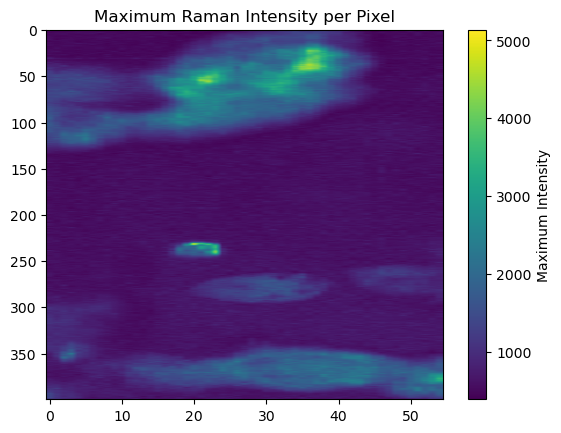

In [8]:
# maximum on the image
plt.imshow(max_intensity, aspect='auto')
plt.colorbar(label='Maximum Intensity')
plt.title('Maximum Raman Intensity per Pixel')
plt.show()

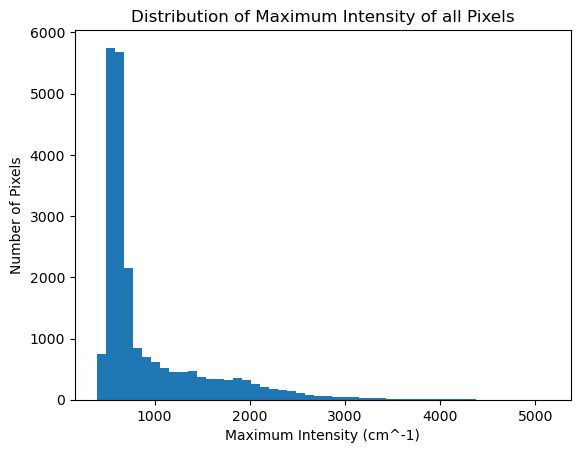

In [6]:
# graph of the maximum
max_vals = max_intensity.flatten()
plt.hist(max_vals, bins=50)
plt.xlabel("Maximum Intensity (cm^-1)")
plt.ylabel("Number of Pixels")
plt.title("Distribution of Maximum Intensity of all Pixels")
plt.show()